# COS30082 – Phase 1: Data Preprocessing



In [1]:
import PIL
import torch
import numpy as np
from facenet_pytorch import MTCNN

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set local project paths

In [3]:
from pathlib import Path

PROJECT_ROOT = Path(r"/Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project")

DATASET_ZIP = PROJECT_ROOT / "dataset.zip"
DATASET_ROOT = PROJECT_ROOT / "dataset"
PROCESSED_ROOT = PROJECT_ROOT / "processed"

CLASS_TRAIN = DATASET_ROOT / "classification_data" / "train_data"
CLASS_VAL   = DATASET_ROOT / "classification_data" / "val_data"
CLASS_TEST  = DATASET_ROOT / "classification_data" / "test_data"
VERIF_DIR   = DATASET_ROOT / "verification_data"
VERIF_PAIRS = DATASET_ROOT / "verification_pairs_val.txt"

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root  :", PROJECT_ROOT)
print("Dataset zip   :", DATASET_ZIP)
print("Dataset root  :", DATASET_ROOT)
print("Processed root:", PROCESSED_ROOT)


Project root  : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project
Dataset zip   : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset.zip
Dataset root  : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset
Processed root: /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/processed


## Extract dataset locally




In [4]:
import zipfile

# unzip dataset if not already unzipped
if CLASS_TRAIN.exists():
    print("Dataset already extracted.")
else:
    if not DATASET_ZIP.exists():
        raise FileNotFoundError()

    print("Unzipping dataset...")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASET_ROOT)

    print("Unzip complete.")

# Check expected folders/files
required_paths = [CLASS_TRAIN, CLASS_VAL, CLASS_TEST, VERIF_DIR, VERIF_PAIRS]

print("\nChecking required paths:")
for p in required_paths:
    print(("✅" if p.exists() else "❌"), p)

missing = [p for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError()




Dataset already extracted.

Checking required paths:
✅ /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset/classification_data/train_data
✅ /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset/classification_data/val_data
✅ /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset/classification_data/test_data
✅ /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset/verification_data
✅ /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset/verification_pairs_val.txt


## Subsample (30 images per identity)

In [6]:
import random
import os

MAX_PER_IDENTITY = 30   # set to None to keep all images

def subsample_split(split_dir, max_imgs):
    split_dir = Path(split_dir)

    if max_imgs is None:
        print("Subsampling disabled — keeping all images.")
        return

    total_before, total_after = 0, 0

    for identity in sorted(os.listdir(split_dir)):
        id_dir = split_dir / identity

        if not id_dir.is_dir():
            continue

        images = [
            f for f in os.listdir(id_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        total_before += len(images)

        if len(images) > max_imgs:
            random.seed(42)

            # This only removes extra files from the extracted local dataset copy.
            for f in random.sample(images, len(images) - max_imgs):
                os.remove(id_dir / f)

        total_after += min(len(images), max_imgs)

    print(f"{split_dir.name}: {total_before:,} → {total_after:,} images")

subsample_split(CLASS_TRAIN, MAX_PER_IDENTITY)


train_data: 380,638 → 119,897 images


## Load MTCNN using CPU


In [7]:
import torch
from facenet_pytorch import MTCNN

# CPU only for now.
device = "cpu"
print(f"Running on: {device}")

mtcnn = MTCNN(
    image_size=112,
    margin=20,
    keep_all=False,
    post_process=True,
    device=device
)

print("MTCNN ready.")


Running on: cpu
MTCNN ready.


## Preprocessing functions

In [8]:
from PIL import Image
from tqdm import tqdm
import numpy as np
import os

BATCH_SIZE = 32

def tensor_to_pil(face_tensor):
    face_tensor = face_tensor.detach().cpu()
    arr = face_tensor.permute(1, 2, 0).numpy()
    arr = ((arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255).astype(np.uint8)
    return Image.fromarray(arr)


def process_folder_batched(input_dir, output_dir):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)
    processed, skipped, already_done = 0, 0, 0

    for identity in tqdm(sorted(os.listdir(input_dir)), desc=input_dir.name):
        in_id  = input_dir / identity
        out_id = output_dir / identity

        if not in_id.is_dir():
            continue

        out_id.mkdir(parents=True, exist_ok=True)

        todo = []
        for f in os.listdir(in_id):
            if not f.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            if (out_id / f).exists():
                already_done += 1
            else:
                todo.append(f)

        for i in range(0, len(todo), BATCH_SIZE):
            batch = todo[i : i + BATCH_SIZE]
            imgs, paths = [], []

            for f in batch:
                try:
                    imgs.append(Image.open(in_id / f).convert("RGB"))
                    paths.append(out_id / f)
                except Exception:
                    skipped += 1

            if not imgs:
                continue

            try:
                faces = mtcnn(imgs)
            except Exception:
                skipped += len(imgs)
                continue

            for face, out_path in zip(faces, paths):
                if face is not None:
                    tensor_to_pil(face).save(out_path)
                    processed += 1
                else:
                    skipped += 1

    return processed, skipped, already_done


def process_flat_folder_batched(input_dir, output_dir):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)
    processed, skipped, already_done = 0, 0, 0

    todo = []
    for f in os.listdir(input_dir):
        if not f.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        if (output_dir / f).exists():
            already_done += 1
        else:
            todo.append(f)

    for i in tqdm(range(0, len(todo), BATCH_SIZE), desc="verification_data"):
        batch = todo[i : i + BATCH_SIZE]
        imgs, paths = [], []

        for f in batch:
            try:
                imgs.append(Image.open(input_dir / f).convert("RGB"))
                paths.append(output_dir / f)
            except Exception:
                skipped += 1

        if not imgs:
            continue

        try:
            faces = mtcnn(imgs)
        except Exception:
            skipped += len(imgs)
            continue

        for face, out_path in zip(faces, paths):
            if face is not None:
                tensor_to_pil(face).save(out_path)
                processed += 1
            else:
                skipped += 1

    return processed, skipped, already_done

print("Preprocessing functions defined.")


Preprocessing functions defined.


## preprocessing

In [9]:
splits = [
    ("train_data", CLASS_TRAIN),
    ("val_data",   CLASS_VAL),
    ("test_data",  CLASS_TEST),
]

for split_name, in_dir in splits:
    out_dir = PROCESSED_ROOT / "classification_data" / split_name
    p, s, done = process_folder_batched(in_dir, out_dir)
    print(f"{split_name}: {p} processed | {s} skipped | {done} already done\n")

VERIF_OUT = PROCESSED_ROOT / "verification_data"
p, s, done = process_flat_folder_batched(VERIF_DIR, VERIF_OUT)
print(f"verification_data: {p} processed | {s} skipped | {done} already done")


train_data: 100%|██████████| 4000/4000 [13:18<00:00,  5.01it/s]


train_data: 110091 processed | 9806 skipped | 0 already done



val_data: 100%|██████████| 4000/4000 [01:17<00:00, 51.92it/s]


val_data: 7936 processed | 64 skipped | 0 already done



test_data: 100%|██████████| 4000/4000 [01:16<00:00, 52.18it/s]


test_data: 7954 processed | 46 skipped | 0 already done



verification_data: 100%|██████████| 2160/2160 [07:46<00:00,  4.63it/s]

verification_data: 63593 processed | 5504 skipped | 0 already done


## Dataset classes

In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


class ClassificationDataset(Dataset):
    def __init__(self, root_dir, transform=EVAL_TRANSFORM):
        root_dir = Path(root_dir)

        self.transform       = transform
        self.samples         = []
        self.identity_to_idx = {}

        for idx, identity in enumerate(sorted(os.listdir(root_dir))):
            id_dir = root_dir / identity

            if not id_dir.is_dir():
                continue

            self.identity_to_idx[identity] = idx

            for fname in os.listdir(id_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((id_dir / fname, idx))

        self.idx_to_identity = {v: k for k, v in self.identity_to_idx.items()}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(Image.open(path).convert("RGB")), label

    @property
    def num_classes(self):
        return len(self.identity_to_idx)


class VerificationDataset(Dataset):
    def __init__(self, pairs_file, img_dir, transform=EVAL_TRANSFORM):
        self.transform = transform
        self.img_dir   = Path(img_dir)
        self.pairs     = []

        with open(pairs_file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 3:
                    self.pairs.append((parts[0], parts[1], int(parts[2])))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1, img2, label = self.pairs[idx]

        def load(name):
            return self.transform(
                Image.open(self.img_dir / name).convert("RGB")
            )

        return load(img1), load(img2), label

print("Dataset classes defined.")


Dataset classes defined.


## DataLoaders

In [11]:
PROC_TRAIN = PROCESSED_ROOT / "classification_data" / "train_data"
PROC_VAL   = PROCESSED_ROOT / "classification_data" / "val_data"
PROC_TEST  = PROCESSED_ROOT / "classification_data" / "test_data"
PROC_VERIF = PROCESSED_ROOT / "verification_data"

train_ds = ClassificationDataset(PROC_TRAIN, transform=TRAIN_TRANSFORM)
val_ds   = ClassificationDataset(PROC_VAL,   transform=EVAL_TRANSFORM)
test_ds  = ClassificationDataset(PROC_TEST,  transform=EVAL_TRANSFORM)
verif_ds = VerificationDataset(VERIF_PAIRS,  PROC_VERIF)

# num_workers=0 is safest for Windows/Jupyter.
# Increase later if it runs correctly.
NUM_WORKERS = 0
BATCH_SIZE_LOADER = 64

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_LOADER,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_LOADER,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE_LOADER,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

verif_loader = DataLoader(
    verif_ds,
    batch_size=BATCH_SIZE_LOADER,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

NUM_CLASSES = train_ds.num_classes

print(f"Train      : {len(train_ds):,} samples")
print(f"Val        : {len(val_ds):,} samples")
print(f"Test       : {len(test_ds):,} samples")
print(f"Identities : {NUM_CLASSES}")
print(f"Verif pairs: {len(verif_ds):,}")

imgs, labels = next(iter(train_loader))
print(f"\nBatch shape : {imgs.shape}")
print(f"Label range : {labels.min().item()} – {labels.max().item()}")
print("\nPhase 1 complete.")


Train      : 110,091 samples
Val        : 7,936 samples
Test       : 7,954 samples
Identities : 4000
Verif pairs: 8,805

Batch shape : torch.Size([64, 3, 112, 112])
Label range : 130 – 3969

Phase 1 complete.


## Visual sanity check

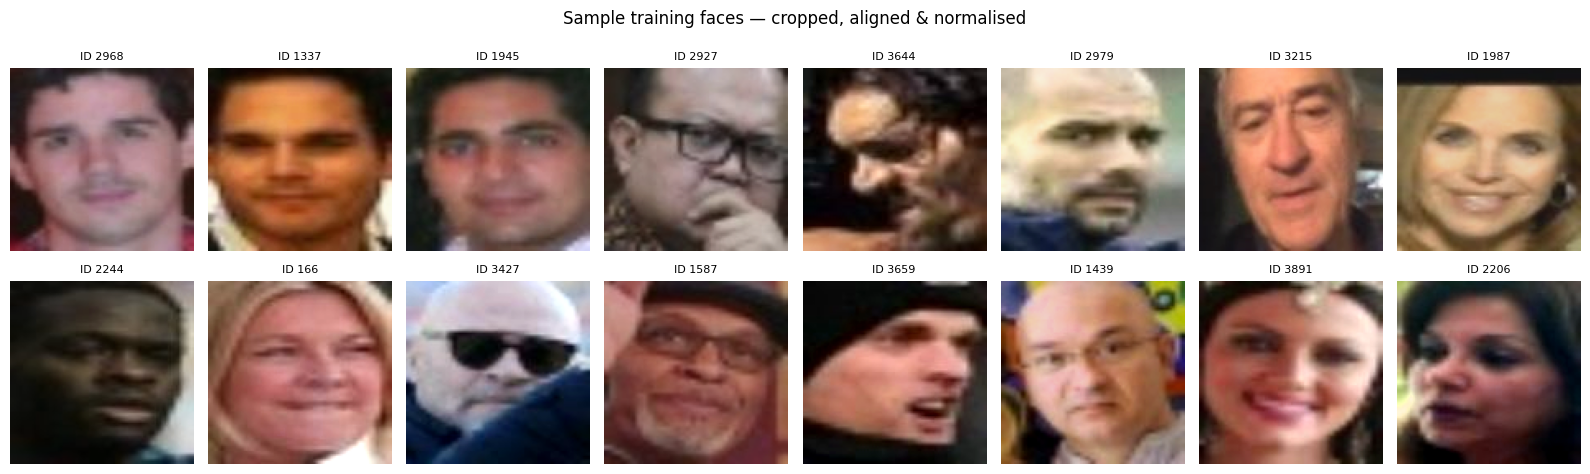

In [12]:
import matplotlib.pyplot as plt

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(imgs[i]).permute(1, 2, 0))
    ax.set_title(f'ID {labels[i].item()}', fontsize=8)
    ax.axis('off')

plt.suptitle('Sample training faces — cropped, aligned & normalised', fontsize=12)
plt.tight_layout()
plt.show()